In [26]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict,Annotated
from dotenv import load_dotenv
from langchain_groq import ChatGroq
import os 
from pydantic import BaseModel,Field
import operator

In [27]:
load_dotenv()

True

In [28]:
model = ChatGroq(model="qwen/qwen3.6-27b",temperature=0)  # Initialize the Groq LLM

In [29]:
class EvaluationState(BaseModel):
    feedback : str = Field(description="Feedbaack for the essay")
    score : float = Field(description="Score for the essay",ge=0,le=10)

In [30]:
structure_model=model.with_structured_output(EvaluationState,method="json_mode")

In [31]:
essay = """
Quantum mechanics, also known as quantum physics, is the fundamental physical theory that describes the behavior of matter and of light; the behaviors it models typically occur at and below the scale of atoms, and have often been described as counterintuitive.[2]: 1.1  Its concepts and methods have been applied across many disciplines, including quantum chemistry, quantum biology, quantum field theory, quantum technology, and quantum information science.

Quantum mechanics can describe many systems that classical physics cannot. Classical physics can describe many aspects of nature at an ordinary (macroscopic and (optical) microscopic) scale; however, it is insufficient for describing them at very small submicroscopic (atomic and subatomic) scales. Classical mechanics can be derived from quantum mechanics as an approximation that is valid at ordinary scales.[3]

Quantum systems have bound states that are quantized to discrete values of energy, momentum, angular momentum, and other quantities, in contrast to classical systems where these quantities can be measured continuously. Measurements of quantum systems show characteristics of both particles and waves (wave–particle duality), and there are limits to how accurately the value of a physical quantity can be predicted prior to its measurement, given a complete set of initial conditions (the uncertainty principle).

Quantum mechanics arose gradually from theories to explain observations that could not be reconciled with classical physics, such as Max Planck's solution in 1900 to the black-body radiation problem, and the correspondence between energy and frequency in Albert Einstein's 1905 paper, which explained the photoelectric effect. These early attempts to understand microscopic phenomena, now known as the "old quantum theory", led to the full development of quantum mechanics in the mid-1920s by Niels Bohr, Erwin Schrödinger, Werner Heisenberg, Max Born, Paul Dirac and others. The modern theory is formulated in various specially developed mathematical formalisms. In one of them, a mathematical entity called the wave function provides information, in the form of probability amplitudes, about what measurements of a particle's energy, momentum, and other physical properties may yield.

"""


In [32]:
prompt = f"""
Evaluate the language quality of the following essay.

Return the evaluation in JSON format with:
- feedback: your feedback about the essay
- score: a score from 0 to 10

Essay:
{essay}
"""

In [33]:
response = structure_model.invoke(prompt)

In [34]:
response.feedback

'The essay demonstrates exceptional language quality. It features precise academic vocabulary, flawless grammar, and a logical, well-structured progression of ideas. Complex scientific concepts are explained clearly and concisely, with appropriate and accurate use of technical terminology. The tone is consistently formal and objective, perfectly matching the subject matter. The only minor observation is the presence of citation markers (e.g., [2]: 1.1), which indicate the text is adapted from a reference source; removing these and adding a brief introductory or concluding sentence would improve its flow as a standalone essay. Overall, the language is highly polished, professional, and effective.'

In [35]:
class UPSCState(TypedDict):
    
    essay : str
    cot_feedback : str #clearity of thughts
    doa_feedback: str #depth of analysis
    language_feedback: str
    final_feedback : str  
    individual_scores : Annotated[list[int],operator.add]
    avg_score : float

In [36]:
graph = StateGraph(UPSCState)

In [37]:
def eval_cot(state: UPSCState) -> UPSCState:
    prompt = f"""
    Evaluate the clarity of thoughts in the following essay.

    Return the result in JSON format with:
    - feedback: detailed feedback about the clarity of thoughts
    - score: an integer from 0 to 10

    Essay:
    {state['essay']}
    """

    response = structure_model.invoke(prompt)

    return {
        "cot_feedback": response.feedback,
        "individual_scores": [response.score]
    }


def eval_language(state: UPSCState) -> UPSCState:
    prompt = f"""
    Evaluate the language clarity in the following essay.

    Return the result in JSON format with:
    - feedback: detailed feedback about the language
    - score: an integer from 0 to 10

    Essay:
    {state['essay']}
    """

    response = structure_model.invoke(prompt)

    return {
        "language_feedback": response.feedback,
        "individual_scores": [response.score]
    }


def eval_doa(state: UPSCState) -> UPSCState:
    prompt = f"""
    Evaluate the depth of analysis in the following essay.

    Return the result in JSON format with:
    - feedback: detailed feedback about the depth of analysis
    - score: an integer from 0 to 10

    Essay:
    {state['essay']}
    """

    response = structure_model.invoke(prompt)

    return {
        "doa_feedback": response.feedback,
        "individual_scores": [response.score]
    }

In [38]:
def eval_final_feedback(state:UPSCState):
    # Combine all feedback and scores
    prompt = f'Based on the following feedback,generate a final feedback \n language_feedback : {state["language_feedback"]} \n cot_feedback : {state["cot_feedback"]} \n doa_feedback : {state["doa_feedback"]}' 
    
    response = model.invoke(prompt)
    
    avg_score = sum(state['individual_scores']) / len(state['individual_scores'])
    return {'final_feedback':response.feedback,'avg_score':avg_score}

In [39]:
graph.add_node("Evaluate Clarity of Thoughts", eval_cot)
graph.add_node("Evaluate Language Quality", eval_language)
graph.add_node("Evaluate Depth of Analysis", eval_doa)
graph.add_node("Generate Final Feedback", eval_final_feedback)

In [40]:
graph.add_edge(START, 'Evaluate Clarity of Thoughts')
graph.add_edge(START, 'Evaluate Language Quality')
graph.add_edge(START, 'Evaluate Depth of Analysis')


graph.add_edge('Evaluate Clarity of Thoughts', 'Generate Final Feedback')
graph.add_edge('Evaluate Language Quality', 'Generate Final Feedback')
graph.add_edge('Evaluate Depth of Analysis', 'Generate Final Feedback')

graph.add_edge('Generate Final Feedback', END)


In [41]:
workflow = graph.compile()

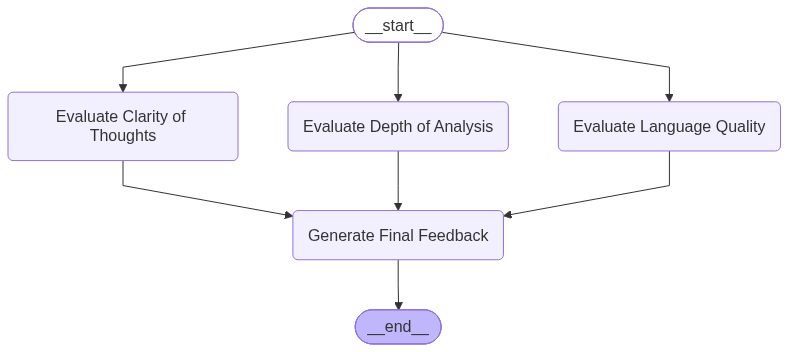

In [42]:
workflow

In [ ]:
intial_state = {
    'essay':essay,
}

final_state = workflow.invoke(intial_state)
final_state